This code helps to analyze wind data from a "YourFileName.csv" and visualize to generate a windrose diagrams.

#Importing necessary libraries and packages

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

!pip install windrose


In [ ]:
df = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/Weather station data/Copy of combined_data.xlsx')

#df.shape  #To Know the number of Rows and Columns
df.info() #Gives the informations related to the data frame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26066 entries, 0 to 26065
Data columns (total 38 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Number         26065 non-null  float64
 1   Device Name    26065 non-null  object 
 2   Device Number  26065 non-null  object 
 3   Receive Time   26065 non-null  object 
 4   Nepal Time     26066 non-null  object 
 5   Nepal Time.1   11523 non-null  object 
 6   Tem            26065 non-null  float64
 7   unit           26065 non-null  object 
 8   Humi           26065 non-null  float64
 9   unit.1         26065 non-null  object 
 10  Light          26065 non-null  float64
 11  unit.2         26065 non-null  object 
 12  Atmos          26065 non-null  float64
 13  unit.3         26065 non-null  object 
 14  Noise          26065 non-null  float64
 15  unit.4         26065 non-null  object 
 16  Ws             26065 non-null  float64
 17  unit.5         26065 non-null  object 
 18  WDIR  

In [ ]:
df_selected = df[
    ['Receive Time', 'Ws', 'unit.5', 'WDIR', 'unit.6']
]

#See whether this works or not by displaying label heads
display(df_selected.head())

#To get the info
df_selected.info()


,Receive Time,Ws,unit.5,WDIR,unit.6
0,2025-06-06 02:14:36,0.0,m/s,62.0,°
1,2025-06-06 02:13:32,0.1,m/s,52.0,°
2,2025-06-06 02:12:28,0.0,m/s,47.0,°
3,2025-06-06 02:11:25,0.0,m/s,196.0,°
4,2025-06-06 02:10:21,0.0,m/s,192.0,°


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26066 entries, 0 to 26065
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Receive Time  26065 non-null  object 
 1   Ws            26065 non-null  float64
 2   unit.5        26065 non-null  object 
 3   WDIR          26065 non-null  float64
 4   unit.6        26065 non-null  object 
dtypes: float64(2), object(3)
memory usage: 1018.3+ KB


## We can further perform such basic analysis like:

Counting the Maximum Wind Speed and Minimum Wind Speed and find their frequency i.e. how many times such maximum and minimum value appears in the dataset.

In [ ]:
print(f"Maximum Wind Speed (Ws): {df_selected['Ws'].max()} m/s")
print(f"Minimum Wind Speed (Ws): {df_selected['Ws'].min()} m/s")


# Count the frequency of maximum wind speeds and print it
max_ws_count = df_selected[df_selected['Ws'] == df_selected['Ws'].max()].shape[0]
print(f"\nFrequency of occurence of maximum wind speeds: {max_ws_count}")

# Count the frequency of minimum wind speeds and print it
min_ws_count = df_selected[df_selected['Ws'] == df_selected['Ws'].min()].shape[0]
print(f"Frequency of occurence of minimum wind speeds: {min_ws_count}\n")

#Or something like:
non_zero_ws_count = df_selected[df_selected['Ws'] != 0].shape[0]
print(f"Number of non-zero wind speeds: {non_zero_ws_count}")

zero_ws_count = df_selected[df_selected['Ws'] == 0].shape[0]
print(f"Number of zero wind speeds: {zero_ws_count}")

Maximum Wind Speed (Ws): 10.5 m/s
Minimum Wind Speed (Ws): 0.0 m/s

Frequency of occurence of maximum wind speeds: 1
Frequency of occurence of minimum wind speeds: 14118

Number of non-zero wind speeds: 11947
Number of zero wind speeds: 14118


## Visualization of the time-variation of wind speed

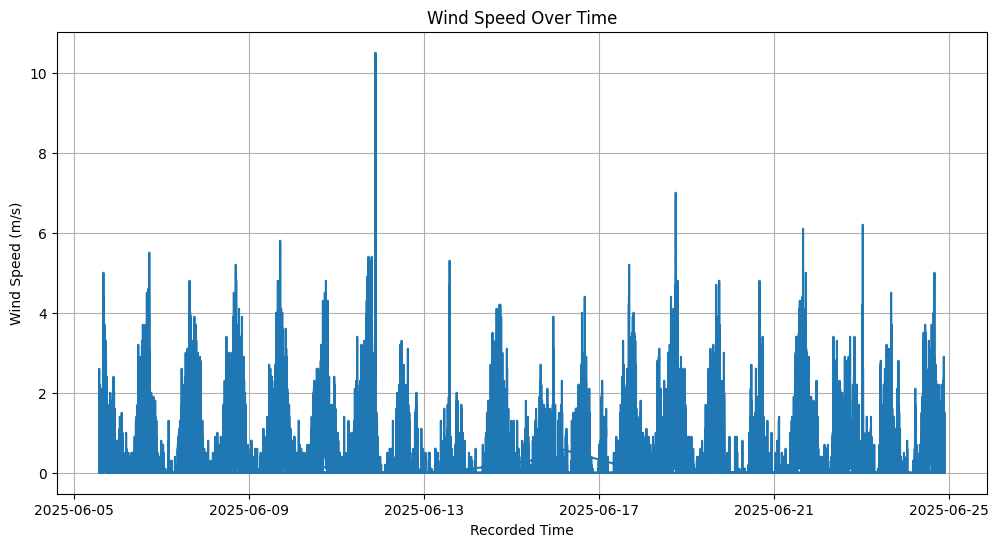

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df_selected.index, df_selected['Ws'])
plt.title('Wind Speed Over Time')
plt.xlabel('Recorded Time')
plt.ylabel('Wind Speed (m/s)')
plt.grid(True)
plt.show()

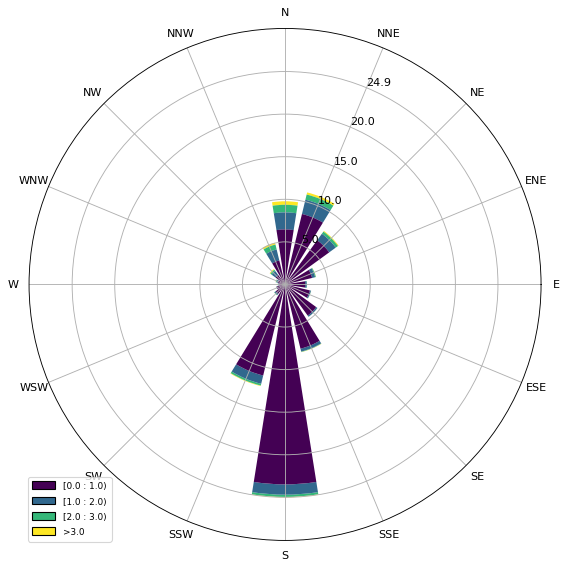

In [ ]:
ax = WindroseAxes.from_ax()
ax.bar(df_selected['WDIR'],
       df_selected['Ws'],
       bins=np.arange(0,4,1),
       normed=True,
       nsector=16
       )

labels = ['N', 'NNE', 'NE', 'ENE', 'E', 'ESE', 'SE', 'SSE','S', 'SSW', 'SW', 'WSW', 'W', 'WNW', 'NW', 'NNW']



# Calculate tick angles starting from North (pi/2 radians) and moving clockwise
# The angles for the center of each sector, starting from North (0 degrees in windrose convention) clockwise are 0, 22.5, 45...
# In standard polar plot (0=East, counter-clockwise), these correspond to pi/2, pi/2 - pi/8, pi/2 - 2*pi/8, ...

#I took help of ai to figure out this line of code sir btw!!!😅
angles_radians = np.linspace(np.pi/2, np.pi/2 - 2*np.pi, 16, endpoint=False) % (2*np.pi)

ax.set_xticks(angles_radians)
ax.set_xticklabels(labels)


ax.set_rmax(30)
ax.set_legend()
plt.show()